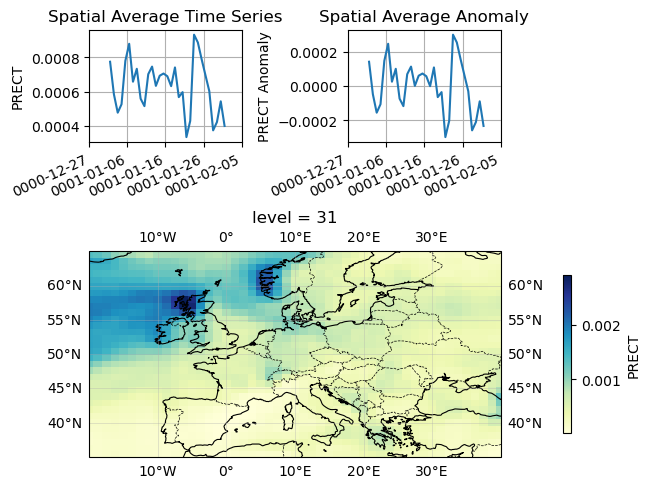

In [52]:
# note to myself: pip install cartopy netcdf4
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature


cam_data = xr.open_dataset('sample_data_camulator.nc')
"""
# Tests from slides:
## View all variables
print("Variables:", list(cam_data.data_vars))
## View dimensions
print("\nDimensions:", dict(cam_data.dims))
## View coordinates
print("\nCoordinates:", list(cam_data.coords))
## Global attributes
print("\nGlobal attributes:", cam_data.attrs)
## Specific variable attributes
print("\nTREFHT attributes:", cam_data['TREFHT'].attrs)
"""
# shift longitude to -180 to 180 to allow slicing across meridian 
cam_data.coords['longitude'] = (cam_data.coords['longitude'] + 180) % 360 - 180
cam_data = cam_data.sortby(cam_data.longitude)

#lat: 35-65N
#long 20W-40E
europe = cam_data.sel(
    latitude=slice(35,65),
    longitude=slice(-20,40)
)

# Plot original values:
# fig, ax = plt.subplots(
#     figsize=(10, 5),
#     subplot_kw={'projection': ccrs.Robinson()}   # 1. Choose map projection
# )
# europe['TREFHT'].isel(time=0).plot(
#     ax=ax,
#     transform=ccrs.PlateCarree(),                # data is on regular lat/lon
#     cmap='plasma',
#     cbar_kwargs={'label': 'TREFHT (K)', 'shrink': 0.7},  
# )
# ax.set_extent([-20, 40, 35, 65], crs=ccrs.PlateCarree())
# ax.coastlines(linewidth=0.8)
# ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--')
# ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
# ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

# Lab Plotting:

europe_spatialAvg = europe['PRECT'].mean(dim=['latitude','longitude'])
europe_timeAvg = europe_spatialAvg.mean(dim='time')
# europe_spatialAvg.plot()
#YlGnBu
axes = plt.figure(layout="constrained").subplot_mosaic(
    """
    AC
    BB
    """,
    height_ratios=[1, 2],
    per_subplot_kw={"B": dict(projection=ccrs.PlateCarree())}
)


axes["A"].plot(europe['time'],europe_spatialAvg)
axes["A"].set_title("Spatial Average Time Series")
axes["A"].set_xticks(axes["A"].get_xticks(), axes["A"].get_xticklabels(), rotation=25, ha='right')
axes["A"].grid()
axes["A"].set_ylabel("PRECT")

axes["C"].plot(europe['time'],europe_spatialAvg-europe_timeAvg)
axes["C"].set_title("Spatial Average Anomaly")
axes["C"].set_xticks(axes["C"].get_xticks(), axes["C"].get_xticklabels(), rotation=25, ha='right')
axes["C"].grid()
axes["C"].set_ylabel("PRECT Anomaly")


europe_timenonsAvg = europe.mean(dim='time')
europe_timenonsAvg['PRECT'].plot(
    ax=axes["B"],
    transform=ccrs.PlateCarree(),                # data is on regular lat/lon
    cmap='YlGnBu',
    cbar_kwargs={'label': 'PRECT', 'shrink': 0.7},  
)
axes["B"].set_extent([-20, 40, 35, 65], crs=ccrs.PlateCarree())

axes["B"].coastlines(linewidth=0.8)
axes["B"].add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--')
axes["B"].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axes["B"].gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
